Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



>>> Training MobileNetV2...


Epoch 5/5: 100%|██████████| 449/449 [00:25<00:00, 17.66it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 194MB/s]



>>> Training DenseNet121...


Epoch 5/5: 100%|██████████| 449/449 [00:42<00:00, 10.47it/s]



--- Table 1: Efficiency and Performance Comparison ---
      Model  Train Samples Comp. Time (s) Test Accuracy  Weighted F1
MobileNetV2          28709        128.43s        59.91%          0.6
DenseNet121          28709        213.16s        59.93%          0.6


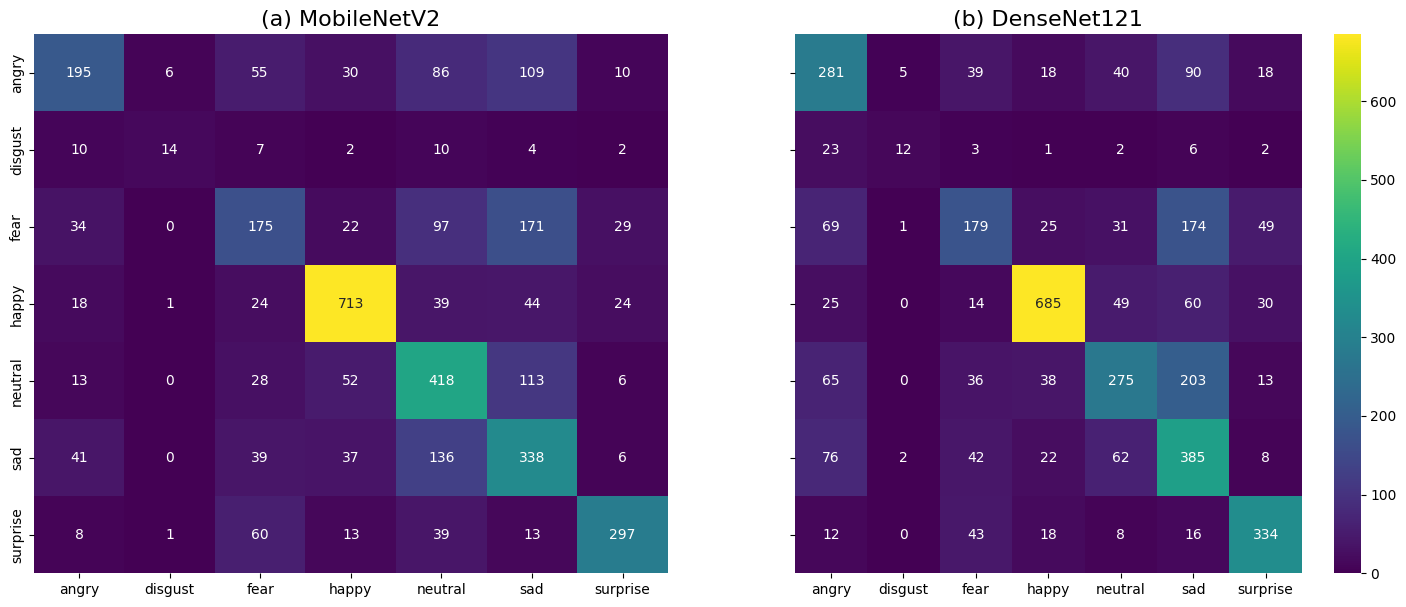

In [5]:
# =================================================================
# 1. DATASET EXTRACTION AND LIBRARIES
# =================================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time # For efficiency measurement
from tqdm import tqdm

# Extracting the dataset if not already present
if not os.path.exists('train'):
    print("Unzipping dataset...")
    !unzip -q fer2013.zip
    print("Unzip complete.")

# Device configuration (T4 GPU recommended)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =================================================================
# 2. DATA PREPARATION
# =================================================================
img_size = 48
batch_size = 64

# Transforms (FER2013 is grayscale, but pre-trained models expect 3 channels)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading datasets
full_train_set = datasets.ImageFolder('train', transform=transform)
test_set = datasets.ImageFolder('test', transform=transform)

# Splitting Test set into Validation and Test (50/50 split)
indices = list(range(len(test_set)))
np.random.shuffle(indices)
split = len(indices) // 2
val_set = Subset(test_set, indices[:split])
actual_test_set = Subset(test_set, indices[split:])

train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(actual_test_set, batch_size=batch_size, shuffle=False)

classes = full_train_set.classes
num_classes = len(classes)

# =================================================================
# 3. UPDATED MODEL DEFINITIONS (MobileNetV2 vs. DenseNet121)
# =================================================================
def get_mobilenet():
    # Efficient baseline
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model.to(device)

def get_densenet121():
    # Sophisticated competitor - closer to ResNet performance
    model = models.densenet121(pretrained=True)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model.to(device)

# =================================================================
# 4. TRAINING AND EVALUATION (Same logic, new models)
# =================================================================
# Note: DenseNet is deeper, so it might take slightly longer than MobileNet
acc_m, f1_m, cm_m, time_m = run_experiment(get_mobilenet(), "MobileNetV2", epochs=5)
acc_d, f1_d, cm_d, time_d = run_experiment(get_densenet121(), "DenseNet121", epochs=5)

# =================================================================
# 5. FINAL RESULTS GENERATION (Single Image)
# =================================================================
results_data = {
    "Model": ["MobileNetV2", "DenseNet121"],
    "Train Samples": [len(full_train_set), len(full_train_set)],
    "Comp. Time (s)": [f"{time_m:.2f}s", f"{time_d:.2f}s"],
    "Test Accuracy": [f"{acc_m:.2f}%", f"{acc_d:.2f}%"],
    "Weighted F1": [round(f1_m, 2), round(f1_d, 2)]
}
df = pd.DataFrame(results_data)
print("\n--- Table 1: Efficiency and Performance Comparison ---")
print(df.to_string(index=False))

# Create and save combined Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
sns.heatmap(cm_m, annot=True, fmt='d', cmap='viridis', xticklabels=classes, yticklabels=classes, ax=ax1, cbar=False)
ax1.set_title("(a) MobileNetV2", fontsize=16)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='viridis', xticklabels=classes, yticklabels=classes, ax=ax2, cbar=True)
ax2.set_title("(b) DenseNet121", fontsize=16)
plt.savefig('baseline_comparison.png', dpi=300, bbox_inches='tight')
plt.show()